<a href="https://colab.research.google.com/github/ivanduzunov/AI-Agents-and-Workflows-for-Developers/blob/main/final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# festival planner
!pip install q langchain langchain-openai

In [68]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.types import interrupt
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.types import Send, interrupt, Command
from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from typing import TypedDict, Literal, List, Annotated, Dict, Optional
from IPython.display import Image
from google.colab import userdata
from pydantic import BaseModel

import uuid

In [69]:
class ConcertPlannerState(TypedDict):
    user_request: str
    festivals: list
    selected_festival: Optional[dict]
    accommodation_type: Optional[str]
    accommodations: list
    selected_accommodation: Optional[dict]
    flights: list
    selected_flight: Optional[dict]
    user_feedback: Optional[str]
    total_price: Optional[float]
    purchase_approved: bool
    final_result: Optional[str]

class Festival(BaseModel):
    name: str
    country: str
    city: str
    price: float
    genre: str
    dates: str

class FestivalResults(BaseModel):
    festivals: list[Festival]

class Accommodation(BaseModel):
    name: str
    country: str
    city: str
    price: float
    type: str


class AccommodationResults(BaseModel):
    accommodations: list[Accommodation]

class Flight(BaseModel):
    airline: str
    departure: str
    arrival: str
    route: str
    price: float
    duration: str


class FlightResults(BaseModel):
    flights: list[Flight]

In [70]:
"""
## Multi-Agent Architecture

The Concert Planner uses 3 distinct AI agents, each with a specialized
role in the workflow.

### 1. Festival Research Agent

**Role:** Festival discovery and recommendation.

**Responsibility:** Analyze the user's request and find suitable music
festivals in Europe based on genre, dates, location and budget.

**Output:** A structured list of festival recommendations that can be
presented to the user for selection.

---

### 2. Accommodation Research Agent

**Role:** Accommodation discovery and recommendation.

**Responsibility:** Find suitable accommodation options near the selected
music festival based on the user's accommodation preference, budget,
location and festival dates.

**Special behavior:** If the user chooses camping, the agent automatically
selects the official festival camping option instead of searching for
hotel options.

**Output:** A structured list of accommodation options that can be
presented to the user for selection.

---

### 3. Travel Planning Agent

**Role:** Flight research and travel planning.

**Responsibility:** After the user selects a festival and accommodation,
find suitable flight options from Sofia to the festival destination based
on the festival dates, destination and reasonable price.

**Output:** A structured list of flight options that can be presented to
the user for selection or revision.

**Human-in-the-Loop:** The user can either select a flight or provide
feedback requesting a revision. When feedback is provided, the Travel
Planning Agent uses it to generate a new set of flight recommendations.

---

## Agent Communication

The agents communicate through the shared `ConcertPlannerState`.

The Festival Research Agent produces festival recommendations. The
Accommodation Research Agent uses the selected festival and the user's
accommodation preference to find suitable accommodation. The Travel
Planning Agent then uses the selected festival and accommodation to
research suitable flight options.

The workflow is coordinated by LangGraph, which controls the execution
order, conditional routing and Human-in-the-Loop interruptions.

---

## Tools

The workflow uses two custom LangChain tools.

### 1. Calculate Total Price

**Purpose:** Calculate the total trip price from the selected festival,
accommodation and flight prices.

**Input:**
- Festival price
- Accommodation price
- Flight price

**Output:** The calculated total trip price.

### 2. Generate Final Summary

**Purpose:** Generate the final Concert Planner result containing the
selected festival, accommodation, flight and total trip price.

**Input:**
- Selected festival
- Selected accommodation
- Selected flight
- Total price

**Output:** A formatted final trip summary presented to the user.

The tools are invoked during the final stage of the workflow, after the
user has approved the purchase.

---

## Test Cases

The workflow was tested with five different user requests.
The test cases cover the main workflow paths, Human-in-the-Loop
interactions, conditional accommodation routing, flight revision,
purchase approval and purchase cancellation.

### Test Case 1 – Rock Festival

**User request:**

> I want a rock festival in Europe during summer.

**Scenario:** Standard successful workflow.

The user selects a festival, accommodation and flight and approves the
final purchase.

**Demonstrates:**
- Festival Research Agent
- Accommodation Research Agent
- Travel Planning Agent
- Human-in-the-Loop selections
- Successful workflow completion

**Invocation:**

```python
execute_workflow(
    "I want a rock festival in Europe during summer."
)
"""

openai_key = userdata.get('OPENAI_KEY')
llm = ChatOpenAI(
    model="gpt-5-nano",
    api_key=openai_key
)

festival_agent = llm.with_structured_output(FestivalResults)
accommodation_agent = llm.with_structured_output(AccommodationResults)
travel_agent = llm.with_structured_output(FlightResults)

FESTIVAL_AGENT_SYSTEM_PROMPT = """
You are the Festival Research Agent for Concert Planner.

Your role is to research and recommend suitable music festivals
in Europe.

Your responsibilities are:
- Analyze the user's music preferences.
- Consider genre, location, dates and budget.
- Find several suitable festival options.
- Return structured festival information.
- Do not make travel or accommodation decisions.

You are responsible only for festival research.
"""

TRAVEL_AGENT_SYSTEM_PROMPT = """
You are the Travel Planning Agent for Concert Planner.

Your role is to plan the user's trip after a festival has been selected.

Your responsibilities are:
- Analyze the selected festival.
- Consider the festival dates and destination.
- Find suitable accommodation options.
- Find suitable flight options.
- Consider price, location and convenience.
- Help create a practical travel plan.

You are responsible for travel and accommodation planning,
not for selecting the festival.
"""

ACCOMMODATION_AGENT_SYSTEM_PROMPT = """
You are the Accommodation Research Agent for Concert Planner.

Your role is to find suitable accommodation for a user
attending a selected music festival.

Your responsibilities are:
- Analyze the selected festival.
- Consider the festival location and dates.
- Consider the user's accommodation preference.
- Consider the user's budget when available.
- Find several suitable accommodation options.
- Prioritize proximity to the festival and good value for money.
- Return structured accommodation information.
- Return at least 2 options no matter how far they are from the festival if you dont find near the festival

If the user chooses camping, use the official festival
camping option when available instead of recommending hotels.

You are responsible only for accommodation research.
You do not select festivals or flights.
"""

In [71]:
def research(state: ConcertPlannerState):

    user_request = state["user_request"]

    result = festival_agent.invoke([
        SystemMessage(content=FESTIVAL_AGENT_SYSTEM_PROMPT),
        HumanMessage(
            content=f"""
            Find suitable music festivals based on this request:

            {state["user_request"]}
            """
        )
    ])

    festivals = [
        festival.model_dump()
        for festival in result.festivals
    ]

    return {
        "festivals": festivals
    }

def select_festival(state: ConcertPlannerState):

    festivals = state["festivals"]

    print("TYPE:", type(festivals))
    print("FESTIVALS:", festivals)

    selection = interrupt({
        "type": "festival_selection",
        "message": "Choose a festival:",
        "options": festivals
    })

    return {
        "selected_festival": festivals[selection]
    }

def select_accommodation_type(state: ConcertPlannerState):

    options = ["hotel", "camping"]

    selection = interrupt({
        "type": "accommodation_type",
        "message": "Where would you like to stay?",
        "options": options
    })

    return {
        "accommodation_type": options[selection]
    }

def find_accommodation(state: ConcertPlannerState):

    festival = state["selected_festival"]
    accommodation_type = state["accommodation_type"]

    if accommodation_type == "camping":

        camping = {
            "name": f"{festival['name']} Official Camping",
            "type": "camping",
            "city": festival["city"],
            "price": 0,
            "description": "Official festival camping."
        }

        print(
            f"\n🏕️ Automatically selected: {camping['name']}"
        )

        return {
            "accommodations": [camping],
            "selected_accommodation": camping
        }

    result = accommodation_agent.invoke([
        SystemMessage(
            content=ACCOMMODATION_AGENT_SYSTEM_PROMPT
        ),
        HumanMessage(
            content=f"""
            Find suitable hotel accommodation for the
            selected music festival.

            Festival:
            {festival}

            Accommodation type:
            {accommodation_type}

            Find several suitable options.

            Consider:
            - proximity to the festival
            - price
            - location
            - value for money
            - festival dates
            """
        )
    ])


    accommodations = [
        accommodation.model_dump()
        for accommodation in result.accommodations
    ]

    print(
        f"\n🏨 Found {len(accommodations)} hotels "
        f"near {festival['city']}"
    )

    return {
        "accommodations": accommodations
    }

def accommodation_router(state: ConcertPlannerState):

    if state["accommodation_type"] == "camping":
        return "travel"

    return "select"

def select_accommodation(state: ConcertPlannerState):

    accommodations = state["accommodations"]

    selection = interrupt({
        "type": "accommodation_selection",
        "message": "Choose accommodation",
        "options": accommodations
    })

    selected = accommodations[selection]

    print(f"\n🏨 Selected: {selected['name']}")

    return {
        "selected_accommodation": selected
    }


def research_travel(state: ConcertPlannerState):

    festival = state["selected_festival"]
    accommodation = state["selected_accommodation"]
    feedback = state.get("user_feedback")

    print("\n✈️ TRAVEL RESEARCH AGENT")

    human_prompt = f"""
    You are a travel research assistant.

    Find suitable flight options for a person
    travelling from Sofia, Bulgaria to the city
    where their selected music festival takes place.

    Festival:
    {festival}

    Selected accommodation:
    {accommodation}

    Consider:
    - destination city
    - festival dates
    - reasonable departure and arrival times
    - reasonable price
    - suitability for attending the festival
    """

    if feedback:
        human_prompt += f"""

    IMPORTANT USER FEEDBACK:

    {feedback}

    Revise the flight recommendations according
    to the user's feedback.

    Do not simply repeat the previous options.
    """

    result = travel_agent.invoke([
        SystemMessage(content=TRAVEL_AGENT_SYSTEM_PROMPT),
        HumanMessage(content=human_prompt)
    ])

    flights = [
        flight.model_dump()
        for flight in result.flights
    ]

    print(f"\n✈️ Found {len(flights)} flight options.")

    return {
        "flights": flights}

def review_flight(state: ConcertPlannerState):

    response = interrupt({
        "type": "flight_review",
        "message": (
            "Review the flight options. "
            "You can select a flight or request a revision."
        ),
        "options": state["flights"]
    })

    if response["action"] == "select":

        selection = response["selection"]

        return {
            "selected_flight": state["flights"][selection],
            "user_feedback": None
        }

    if response["action"] == "revise":

        return {
            "selected_flight": None,
            "user_feedback": response["feedback"]
        }

def flight_review_router(state: ConcertPlannerState):

    if state["selected_flight"] is not None:
        return "continue"

    return "revise"

def confirm_purchase(state: ConcertPlannerState):

    festival = state["selected_festival"]
    accommodation = state["selected_accommodation"]
    flight = state["selected_flight"]

    total_price = (
        festival["price"]
        + accommodation["price"]
        + flight["price"]
    )

    approval = interrupt({
        "type": "purchase_confirmation",
        "message": "Please review your trip before purchase.",
        "festival": festival,
        "accommodation": accommodation,
        "flight": flight,
        "total_price": total_price
    })

    return {
        "purchase_approved": approval
    }

def buy_tickets(state: ConcertPlannerState):

    if not state["purchase_approved"]:
        return {
            "final_result": "Purchase cancelled by user."
        }

    print("\n💳 PURCHASING...")

    festival = state["selected_festival"]
    accommodation = state["selected_accommodation"]
    flight = state["selected_flight"]

    total_price = calculate_total_price.invoke({
        "festival_price": festival["price"],
        "accommodation_price": accommodation["price"],
        "flight_price": flight["price"]
    })

    result = generate_final_summary.invoke({
        "festival": festival,
        "accommodation": accommodation,
        "flight": flight,
        "total_price": total_price
    })

    return {
        "final_result": result,
        "total_price": total_price
    }

In [72]:
@tool
def generate_final_summary(
    festival: dict,
    accommodation: dict,
    flight: dict,
    total_price: float
) -> str:
    """
    Prints and formats the final Concert Planner trip result.
    """

    result = f"""
    ==============================
          CONCERT PLANNER
    ==============================

    🎵 FESTIVAL
    {festival['name']}
    {festival['city']}, {festival['country']}
    Dates: {festival['dates']}
    Price: €{festival['price']}

    🏨 ACCOMMODATION
    {accommodation['name']}
    {accommodation['city']}
    Price: €{accommodation['price']}

    ✈️ FLIGHT
    {flight['airline']}
    {flight['route']}
    Departure: {flight['departure']}
    Arrival: {flight['arrival']}
    Price: €{flight['price']}

    💰 TOTAL PRICE
    €{total_price}

    ==============================
    """

    print(result)

    return result



@tool
def calculate_total_price(
    festival_price: float,
    accommodation_price: float,
    flight_price: float
) -> float:

    """
    Calculate the total price of the festival trip.
    """
    return (
        festival_price
        + accommodation_price
        + flight_price
    )

In [73]:
graph_builder = StateGraph(ConcertPlannerState)

graph_builder.add_node("Research", research)
graph_builder.add_node("Select Festival", select_festival)
graph_builder.add_node("Select Accommodation Type", select_accommodation_type)
graph_builder.add_node("Find Accommodation", find_accommodation)
graph_builder.add_node("Select Accommodation", select_accommodation)

graph_builder.add_node("Research Travel", research_travel)
graph_builder.add_node("Review Flight", review_flight)

graph_builder.add_node("Confirm Purchase", confirm_purchase)
graph_builder.add_node("Buy Tickets", buy_tickets)


graph_builder.add_edge(START, "Research")

graph_builder.add_edge(
    "Research",
    "Select Festival"
)

graph_builder.add_edge(
    "Select Festival",
    "Select Accommodation Type"
)

graph_builder.add_edge(
    "Select Accommodation Type",
    "Find Accommodation"
)

graph_builder.add_conditional_edges(
    "Find Accommodation",
    accommodation_router,
    {
        "select": "Select Accommodation",
        "travel": "Research Travel"
    }
)

graph_builder.add_edge(
    "Select Accommodation",
    "Research Travel"
)

graph_builder.add_edge(
    "Research Travel",
    "Review Flight"
)

graph_builder.add_conditional_edges(
    "Review Flight",
    flight_review_router,
    {
        "continue": "Confirm Purchase",
        "revise": "Research Travel"
    }
)

graph_builder.add_edge(
    "Confirm Purchase",
    "Buy Tickets"
)

graph_builder.add_edge(
    "Buy Tickets",
    END
)


checkpointer = InMemorySaver()

graph = graph_builder.compile(
    debug=True,
    checkpointer=checkpointer
)


In [74]:
def execute_workflow(user_request: str):

    config = {
        "configurable": {
            "thread_id": str(uuid.uuid4())
        }
    }

    initial_state = {
        "user_request": user_request,
        "festivals": [],
        "user_feedback": None,
        "selected_festival": None,
        "accommodation_type": None,
        "accommodations": [],
        "selected_accommodation": None,
        "total_price": None,
        "flights": [],
        "selected_flight": None,
        "purchase_approved": False,
        "final_result": None
    }

    result = graph.invoke(
        initial_state,
        config=config
    )

    while "__interrupt__" in result:

        interrupt_value = result["__interrupt__"][0].value
        interrupt_type = interrupt_value.get("type")

        print("\n" + "=" * 60)

        # -----------------------------
        # Selection interrupts
        # -----------------------------

        if interrupt_type in [
            "festival_selection",
            "accommodation_type",
            "accommodation_selection"
        ]:

            print(interrupt_value["message"])
            print("=" * 60)

            options = interrupt_value["options"]

            for i, option in enumerate(options):

                print(f"\n[{i}]")

                if isinstance(option, dict):

                    for key, value in option.items():
                        print(f"{key}: {value}")

                else:
                    print(option)

            selection = int(
                input("\nYour choice: ")
            )

            result = graph.invoke(
                Command(resume=selection),
                config=config
            )

        # -----------------------------
        # Flight review / revision
        # -----------------------------

        elif interrupt_type == "flight_review":

            print(interrupt_value["message"])
            print("=" * 60)

            options = interrupt_value["options"]

            for i, option in enumerate(options):

                print(f"\n[{i}]")

                for key, value in option.items():
                    print(f"{key}: {value}")

            print("\nOptions:")
            print("  select <number>")
            print("  revise <feedback>")

            user_input = input(
                "\nYour choice: "
            ).strip()

            if user_input.startswith("select "):

                selection = int(
                    user_input.split(" ", 1)[1]
                )

                result = graph.invoke(
                    Command(
                        resume={
                            "action": "select",
                            "selection": selection
                        }
                    ),
                    config=config
                )

            elif user_input.startswith("revise "):

                feedback = user_input.split(
                    " ",
                    1
                )[1]

                result = graph.invoke(
                    Command(
                        resume={
                            "action": "revise",
                            "feedback": feedback
                        }
                    ),
                    config=config
                )

            else:

                print(
                    "\nInvalid input."
                )

                print(
                    "Use 'select <number>' "
                    "or 'revise <feedback>'."
                )

        # -----------------------------
        # Purchase confirmation
        # -----------------------------

        elif interrupt_type == "purchase_confirmation":

            print(interrupt_value["message"])
            print("=" * 60)

            print("\n🎵 FESTIVAL")
            print(interrupt_value["festival"])

            print("\n🏨 ACCOMMODATION")
            print(interrupt_value["accommodation"])

            print("\n✈️ FLIGHT")
            print(interrupt_value["flight"])

            print(
                f"\n💰 TOTAL: "
                f"{interrupt_value['total_price']}"
            )

            answer = input(
                "\nDo you want to proceed with the purchase? "
                "(yes/no): "
            ).strip().lower()

            approval = answer in ["yes", "y"]

            result = graph.invoke(
                Command(resume=approval),
                config=config
            )

        else:

            raise ValueError(
                f"Unknown interrupt type: {interrupt_type}"
            )

    return result



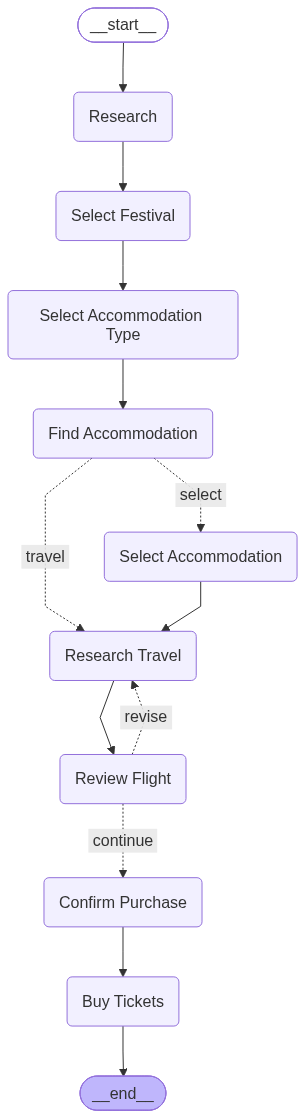

In [83]:
display(Image(graph.get_graph(xray=True).draw_mermaid_png(), format="png"))

In [ ]:
execute_workflow("I want a rock festival in Europe during summer.")

In [ ]:
execute_workflow("I want a hip-hop festival in Europe during summer.")

In [ ]:
execute_workflow("I want an electronic music festival in Europe during summer.")

In [ ]:
execute_workflow("I want a metal festival in Europe during summer.")

In [82]:
execute_workflow("Find me an indie or alternative music festival in Poland in July.")

[values] {'user_request': 'Find me an indie or alternative music festival in Poland in July.', 'festivals': [], 'selected_festival': None, 'accommodation_type': None, 'accommodations': [], 'selected_accommodation': None, 'flights': [], 'selected_flight': None, 'user_feedback': None, 'total_price': None, 'purchase_approved': False, 'final_result': None}
[updates] {'Research': {'festivals': [{'name': 'OFF Festival', 'country': 'Poland', 'city': 'Kraków', 'price': 350.0, 'genre': 'Indie/Alternative/Experimental', 'dates': 'July (dates vary yearly)'}, {'name': 'Audioriver Festival', 'country': 'Poland', 'city': 'Płock', 'price': 320.0, 'genre': 'Electronic/Indie/Alternative', 'dates': 'July (dates vary yearly)'}, {'name': 'Castle Party', 'country': 'Poland', 'city': 'Bolków', 'price': 200.0, 'genre': 'Goth/Industrial/Alternative', 'dates': 'July (dates vary yearly)'}, {'name': "Open'er Festival", 'country': 'Poland', 'city': 'Gdynia', 'price': 900.0, 'genre': 'Indie/Alternative/Rock/Pop', 

{'user_request': 'Find me an indie or alternative music festival in Poland in July.',
 'festivals': [{'name': 'OFF Festival',
   'country': 'Poland',
   'city': 'Kraków',
   'price': 350.0,
   'genre': 'Indie/Alternative/Experimental',
   'dates': 'July (dates vary yearly)'},
  {'name': 'Audioriver Festival',
   'country': 'Poland',
   'city': 'Płock',
   'price': 320.0,
   'genre': 'Electronic/Indie/Alternative',
   'dates': 'July (dates vary yearly)'},
  {'name': 'Castle Party',
   'country': 'Poland',
   'city': 'Bolków',
   'price': 200.0,
   'genre': 'Goth/Industrial/Alternative',
   'dates': 'July (dates vary yearly)'},
  {'name': "Open'er Festival",
   'country': 'Poland',
   'city': 'Gdynia',
   'price': 900.0,
   'genre': 'Indie/Alternative/Rock/Pop',
   'dates': 'July (dates vary yearly)'}],
 'selected_festival': {'name': 'Castle Party',
  'country': 'Poland',
  'city': 'Bolków',
  'price': 200.0,
  'genre': 'Goth/Industrial/Alternative',
  'dates': 'July (dates vary yearly)'